In [1]:
import requests
from bs4 import BeautifulSoup
import re

In [2]:
price=[]
ownership=[]
kilometer=[]
registration_year=[]
location=[]
brand=[]
model=[]
uploaded_date=[]
url="https://bikekharido.in/used-bikes-in-india/?sf_paged="
total_pages=54
for i in range(1,total_pages+1):
    real_url=f"{url}{i}"
    header_get={'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 Safari/537.36 Edg/140.0.0.0'}
    page=requests.get(real_url,headers=header_get)
    soup=BeautifulSoup(page.text)
    for j in soup.find_all("div",class_="fl-post-text"):
        r1=re.findall(r'\s*[a-zA-Z]+\s*\d{1,2},\s*\d{4}',j.text)
        match1=re.findall(r'^\s*\d{4}\s*(\w+)\s*',j.text)
        match = re.findall(r'^\s*(\d{4})',j.text)
        match2=re.findall(r'^\s*\d{4}\s*\w+\s*(.*)',j.text)
        r2=j.find("div",class_="otherDetails")
        kilo=re.findall(r'\s*KM\s*Driven\s*\n\s*(\d+)',r2.text)
       # kilo=j.find("span",class_='boxlabel imptags')
        rate1=re.findall(r'₹\s\d+,\d{3}', j.text)
        rate2=re.findall(r'₹ \d,\d{2},\d+',j.text)
        locs=j.find("div",class_="otherDetails")
        loc=re.findall(r'\s*Location\s*\n\s*(\w+)',locs.text)
        owners=j.find("div",class_="otherDetails")
        owner=re.findall(r'Ownership\s*\n\s*(\w+)',owners.text)
        if rate1 or rate2:
            if rate1:
                price.append(rate1[0][2:])
            if rate2:
                price.append(rate2[0][2:])
        else:
            price.append(None)
        if kilo:
            kilometer.append(kilo[0])
        else:
            kilometer.append(None)
        if owner:
            ownership.append(owner[0])
        else:
            ownership.append(None)
         
        if loc:
            location.append(loc[0])
        else:
            location.append(None)
        
        if match:
            registration_year.append(match[0])
        else:
            registration_year.append(None)
       
        if match1:
            brand.append(match1[0])
        else:
            brand.append(None)
        
        if match2:
            model.append(match2[0])
        else:
            model.append(None)
        
        for i in r1:
            if i:
                uploaded_date.append(i[7:])
            else:
                uploaded_date.append(None)
        


In [3]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
import pandas as pd

In [5]:
data={'Registration Year':registration_year,'Brand':brand,'Model':model,'Price':price,'Uploaded Date':uploaded_date,'Kilometer':kilometer,'Location':location,'Ownership':ownership}

In [21]:
df=pd.DataFrame(data)


In [22]:
df

,Registration Year,Brand,Model,Price,Uploaded Date,Kilometer,Location,Ownership
0,2022,Hero,Passion Pro i3s Disc Alloy,"55,000","August 7, 2025",30000,Bangalore,First
1,2017,Bajaj,Pulsar NS160 STD,"40,000","August 7, 2025",27500,Delhi,Third
2,2017,Bajaj,Pulsar NS200 STD BS4,"55,000","August 7, 2025",66850,Hyderabad,First
3,2017,Bajaj,Dominar 400 (2016-2018) ABS,"1,10,000","August 7, 2025",35000,Jodhpur,First
4,2017,Royal,Enfield Classic 350 Redditch Series With Singl...,"1,45,000","August 7, 2025",50000,Bangalore,First
...,...,...,...,...,...,...,...,...
1269,2017,Bajaj,Avenger Street 160,"45,000","April 29, 2023",30000,Delhi,First
1270,2018,Hero,Super Splendor Canvas Black Edition Drum,"42,000","April 11, 2023",20000,Delhi,Second
1271,2022,Royal,Enfield Classic 350 Chrome Series With Dual-Ch...,"2,00,000","April 11, 2023",15000,Allahabad,First
1272,2013,Honda,Dream Yuga 110,"30,000","April 5, 2023",80000,Bangalore,Second


In [23]:
df.isnull().sum()

Registration Year    2
Brand                2
Model                2
Price                0
Uploaded Date        0
Kilometer            2
Location             0
Ownership            0
dtype: int64

In [24]:
df["Brand"] = df["Brand"].str.strip().str.title() 
df["Brand"] = df["Brand"].replace({
    "Royal": "Royal Enfield"
})

In [25]:
df["Model"] = df["Model"].str.replace("Enfield", "", case=False, regex=True).str.strip()



In [35]:
brand_name=df['Brand'].mode()[0]
brand_name

'Bajaj'

In [36]:
df['Brand'].fillna(brand_name,inplace=True)


In [37]:
model_name=df['Model'].mode()[0]
model_name

'Activa'

In [38]:
df['Model'].fillna(model_name,inplace=True)

In [47]:
kilometers = df['Kilometer'].mode()[0] 
df['Kilometer'].fillna(kilometers, inplace=True)


In [49]:
reg_year = df['Registration Year'].mode()[0]
df['Registration Year'].fillna(reg_year, inplace=True)

In [50]:
df.isnull().sum()

Registration Year    0
Brand                0
Model                0
Price                0
Uploaded Date        0
Kilometer            0
Location             0
Ownership            0
dtype: int64

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Registration Year  1274 non-null   object
 1   Brand              1274 non-null   object
 2   Model              1274 non-null   object
 3   Price              1274 non-null   object
 4   Uploaded Date      1274 non-null   object
 5   Kilometer          1274 non-null   object
 6   Location           1274 non-null   object
 7   Ownership          1274 non-null   object
dtypes: object(8)
memory usage: 79.8+ KB


In [52]:
df['Registration Year']=df['Registration Year'].astype('int')

In [53]:
df['Price']=df['Price'].str.replace(",","")

In [54]:
df['Price']=df['Price'].astype('int')

In [55]:
df['Kilometer']=df['Kilometer'].astype('int')

In [58]:
df['Uploaded Date']=pd.to_datetime(df['Uploaded Date'])



In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1274 entries, 0 to 1273
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Registration Year  1274 non-null   int32         
 1   Brand              1274 non-null   object        
 2   Model              1274 non-null   object        
 3   Price              1274 non-null   int32         
 4   Uploaded Date      1274 non-null   datetime64[ns]
 5   Kilometer          1274 non-null   int32         
 6   Location           1274 non-null   object        
 7   Ownership          1274 non-null   object        
dtypes: datetime64[ns](1), int32(3), object(4)
memory usage: 64.8+ KB


In [60]:
df.describe()

,Registration Year,Price,Uploaded Date,Kilometer
count,1274.000000,1274.000000,1274,1274.000000
mean,2018.202512,98006.803768,2023-12-20 01:57:33.061224448,26050.171115
min,2007.000000,10000.000000,2023-04-05 00:00:00,273.000000
25%,2016.000000,45000.000000,2023-09-13 00:00:00,10000.000000
50%,2019.000000,75000.000000,2023-10-27 00:00:00,20000.000000
75%,2021.000000,140000.000000,2024-02-12 00:00:00,35000.000000
max,2024.000000,850000.000000,2025-08-07 00:00:00,200000.000000
std,3.607811,81202.392288,NaN,22914.232927


In [61]:
df.head(5)

,Registration Year,Brand,Model,Price,Uploaded Date,Kilometer,Location,Ownership
0,2022,Hero,Passion Pro i3s Disc Alloy,55000,2025-08-07,30000,Bangalore,First
1,2017,Bajaj,Pulsar NS160 STD,40000,2025-08-07,27500,Delhi,Third
2,2017,Bajaj,Pulsar NS200 STD BS4,55000,2025-08-07,66850,Hyderabad,First
3,2017,Bajaj,Dominar 400 (2016-2018) ABS,110000,2025-08-07,35000,Jodhpur,First
4,2017,Royal Enfield,Classic 350 Redditch Series With Single-Channel,145000,2025-08-07,50000,Bangalore,First


In [62]:
df.tail(5)

,Registration Year,Brand,Model,Price,Uploaded Date,Kilometer,Location,Ownership
1269,2017,Bajaj,Avenger Street 160,45000,2023-04-29,30000,Delhi,First
1270,2018,Hero,Super Splendor Canvas Black Edition Drum,42000,2023-04-11,20000,Delhi,Second
1271,2022,Royal Enfield,Classic 350 Chrome Series With Dual-Channel,200000,2023-04-11,15000,Allahabad,First
1272,2013,Honda,Dream Yuga 110,30000,2023-04-05,80000,Bangalore,Second
1273,2013,Honda,Dream Yuga 110,30000,2023-04-05,80000,Bangalore,Second


In [63]:
df.to_csv('Bikes.csv',index=False)

In [64]:
bike=pd.read_csv('Bikes.csv')
bike

,Registration Year,Brand,Model,Price,Uploaded Date,Kilometer,Location,Ownership
0,2022,Hero,Passion Pro i3s Disc Alloy,55000,2025-08-07,30000,Bangalore,First
1,2017,Bajaj,Pulsar NS160 STD,40000,2025-08-07,27500,Delhi,Third
2,2017,Bajaj,Pulsar NS200 STD BS4,55000,2025-08-07,66850,Hyderabad,First
3,2017,Bajaj,Dominar 400 (2016-2018) ABS,110000,2025-08-07,35000,Jodhpur,First
4,2017,Royal Enfield,Classic 350 Redditch Series With Single-Channel,145000,2025-08-07,50000,Bangalore,First
...,...,...,...,...,...,...,...,...
1269,2017,Bajaj,Avenger Street 160,45000,2023-04-29,30000,Delhi,First
1270,2018,Hero,Super Splendor Canvas Black Edition Drum,42000,2023-04-11,20000,Delhi,Second
1271,2022,Royal Enfield,Classic 350 Chrome Series With Dual-Channel,200000,2023-04-11,15000,Allahabad,First
1272,2013,Honda,Dream Yuga 110,30000,2023-04-05,80000,Bangalore,Second


## Exploratory Data Anaylsis

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [66]:
bike=pd.read_csv('Bikes.csv')

In [67]:
bike

,Registration Year,Brand,Model,Price,Uploaded Date,Kilometer,Location,Ownership
0,2022,Hero,Passion Pro i3s Disc Alloy,55000,2025-08-07,30000,Bangalore,First
1,2017,Bajaj,Pulsar NS160 STD,40000,2025-08-07,27500,Delhi,Third
2,2017,Bajaj,Pulsar NS200 STD BS4,55000,2025-08-07,66850,Hyderabad,First
3,2017,Bajaj,Dominar 400 (2016-2018) ABS,110000,2025-08-07,35000,Jodhpur,First
4,2017,Royal Enfield,Classic 350 Redditch Series With Single-Channel,145000,2025-08-07,50000,Bangalore,First
...,...,...,...,...,...,...,...,...
1269,2017,Bajaj,Avenger Street 160,45000,2023-04-29,30000,Delhi,First
1270,2018,Hero,Super Splendor Canvas Black Edition Drum,42000,2023-04-11,20000,Delhi,Second
1271,2022,Royal Enfield,Classic 350 Chrome Series With Dual-Channel,200000,2023-04-11,15000,Allahabad,First
1272,2013,Honda,Dream Yuga 110,30000,2023-04-05,80000,Bangalore,Second


# UNIVARIATE ANALYSIS

### COUNT OF EACH AND EVERY BRAND

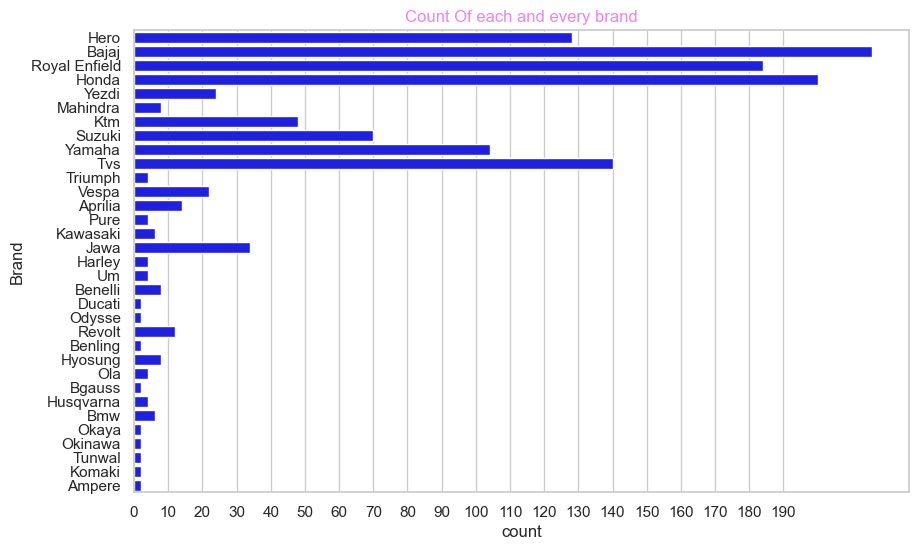

In [68]:
sns.countplot(data=bike,y='Brand',color='blue')
plt.xticks(range(0,200,10))
plt.title("Count Of each and every brand",color='VIOLET')

plt.show()

## Top 10 models

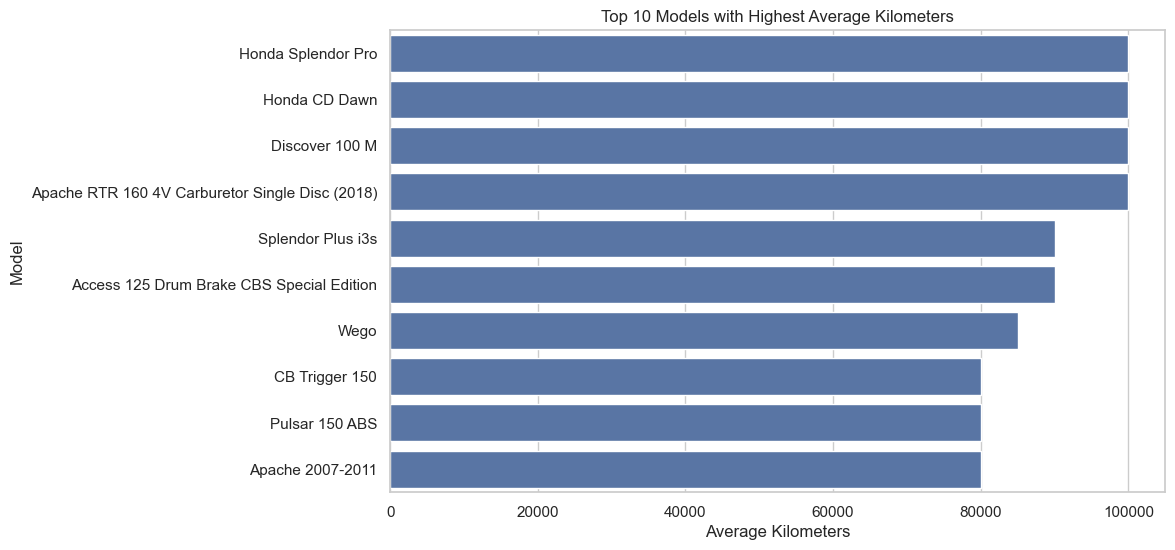

In [69]:
top_km_models = bike.groupby('Model')['Kilometer'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_km_models.values, y=top_km_models.index)
plt.title('Top 10 Models with Highest Average Kilometers')
plt.xlabel('Average Kilometers')
plt.ylabel('Model')
plt.show()


## Count Of Whether The Bike Is (FIRST OR SECOND OR THIRD)

In [94]:
ownership_counts=bike.value_counts('Ownership')
ownership_counts

Ownership
First     1060
Second     172
Third       32
Above       10
Name: count, dtype: int64

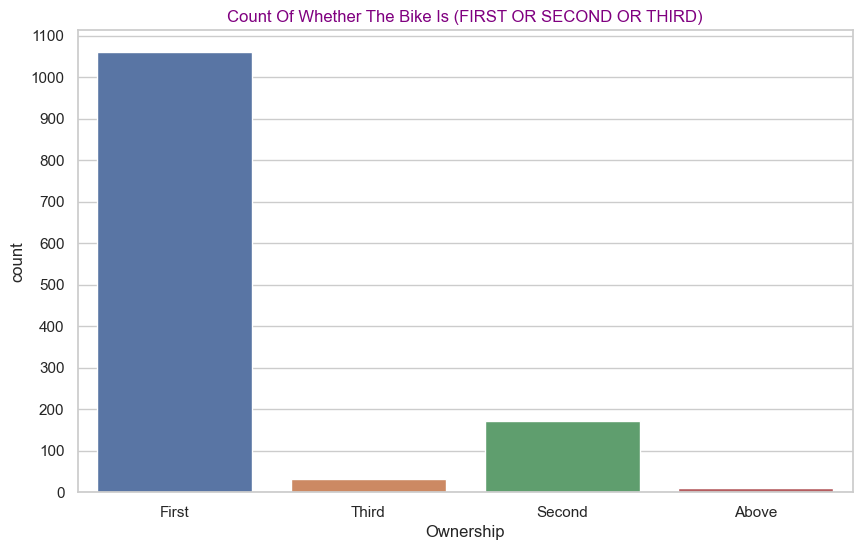

In [95]:
sns.countplot(data=bike,x='Ownership',hue='Ownership')
plt.yticks(range(0,1200,100))
plt.title("Count Of Whether The Bike Is (FIRST OR SECOND OR THIRD)",color='Purple')
plt.show()

## Maxprice In  Every Brand

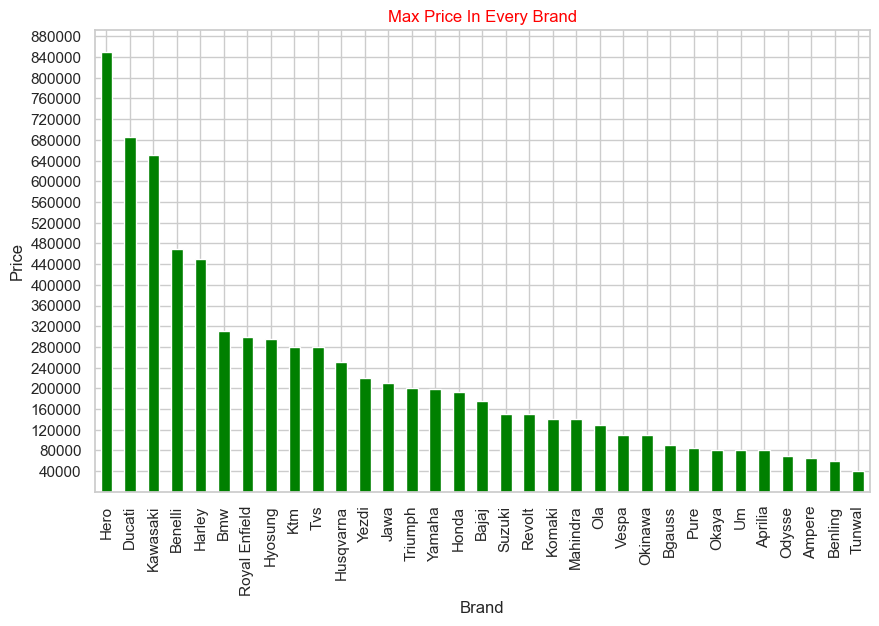

In [96]:
max_price=bike.groupby('Brand')['Price'].max().sort_values(ascending=False)
max_price.plot(kind='bar',color='green')
plt.yticks(range(40000,900000,40000))
plt.title("Max Price In Every Brand",color='red')
plt.ylabel("Price")
plt.show()

### HOW MANY VEHICLES REGISTERED IN EVERY YEAR

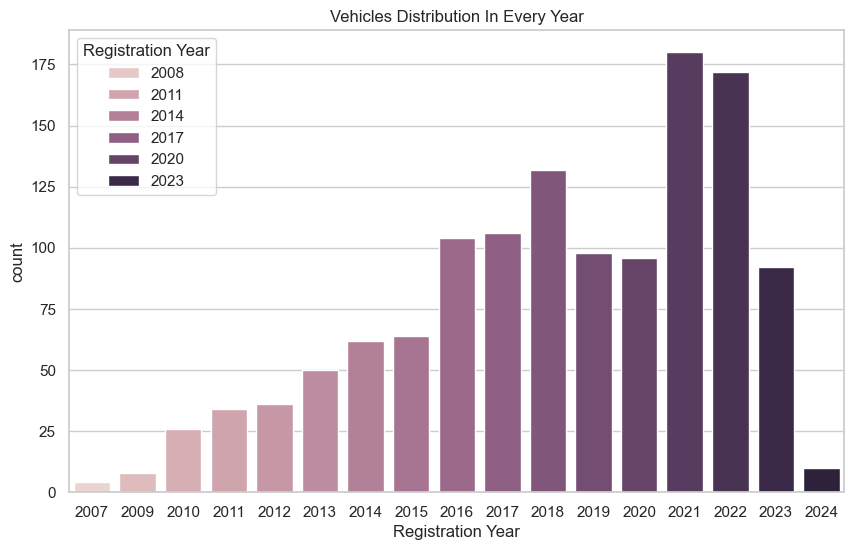

In [15]:
sns.countplot(data=bike,x='Registration Year',hue='Registration Year')
plt.title("Vehicles Distribution In Every Year")
plt.show()

### Top 5  Each Location

In [99]:
top_5_locations = bike['Location'].value_counts().head(5)
#print(top_5_locations)


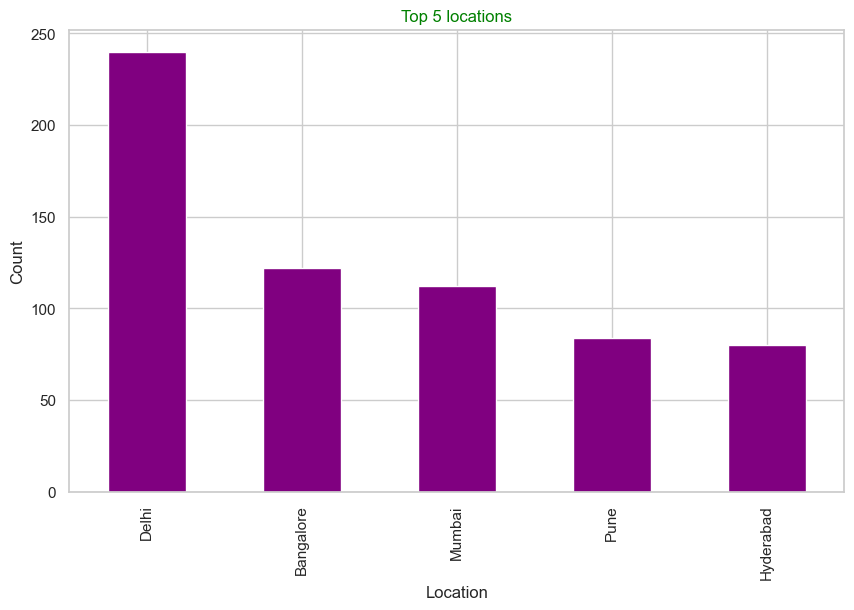

In [100]:
top_5_locations.plot(kind='bar',color='purple')
plt.title("Top 5 locations",color='Green')
plt.ylabel("Count")
plt.show()

## OwnerShiP Dsitribution

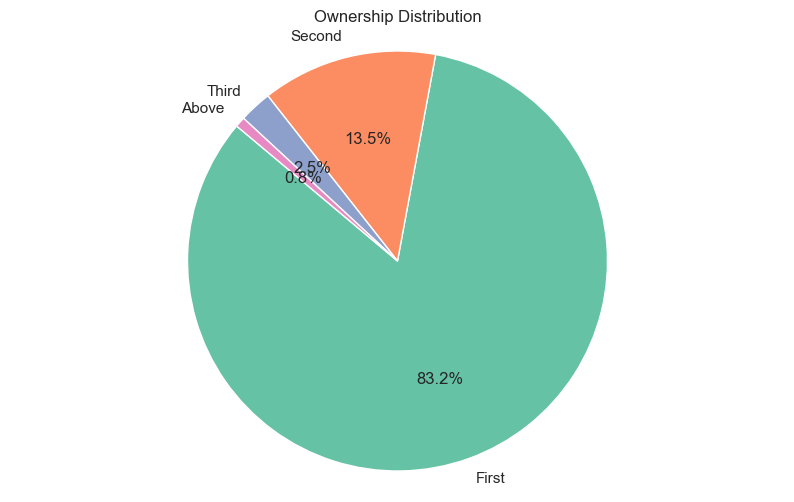

In [101]:
ownership_counts = bike['Ownership'].value_counts()
plt.pie(ownership_counts.values, labels=ownership_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title("Ownership Distribution")
plt.axis('equal')
plt.show()


# BIVARIATE ANAYLSIS

### Average Price By Each Brand

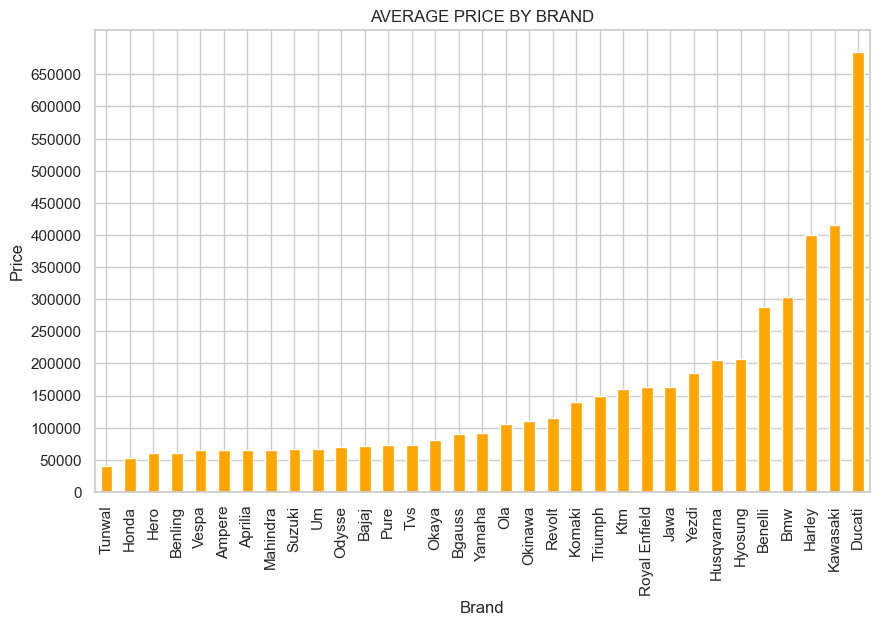

In [13]:
avg_price=bike.groupby('Brand')['Price'].mean().sort_values(ascending=True)
avg_price.plot(kind='bar',color='Orange')
plt.yticks(range(0,700000,50000))
plt.title("AVERAGE PRICE BY BRAND")
plt.xlabel("Brand")
plt.ylabel("Price")
plt.show()


## Kilometers Driven Vs Price

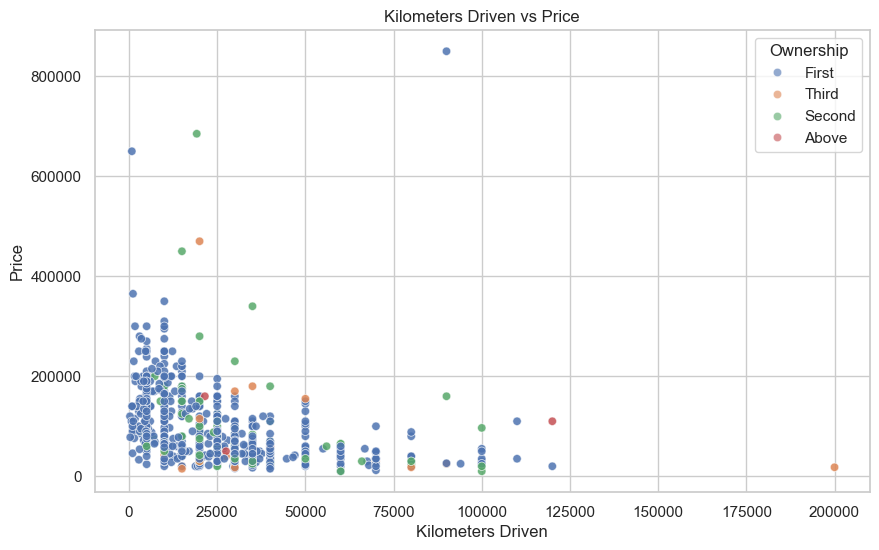

In [102]:

sns.scatterplot(data=bike, x='Kilometer', y='Price', hue='Ownership', alpha=0.6)
plt.title('Kilometers Driven vs Price')
plt.xlabel('Kilometers Driven')
plt.ylabel('Price')
plt.
plt.legend(title='Ownership')
plt.show()


##  Onwership VS Price Distribution


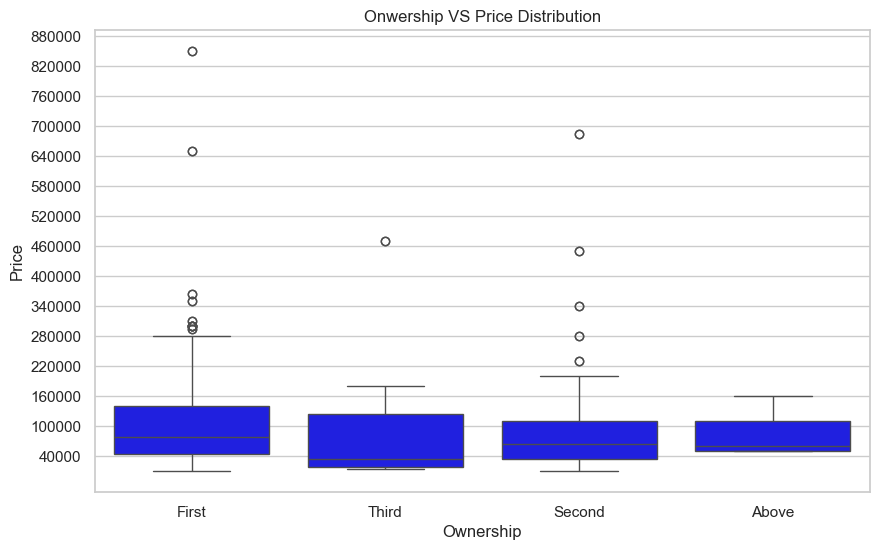

In [17]:
sns.boxplot(data=bike, x='Ownership', y='Price',color='blue')
plt.title('Onwership VS Price Distribution')
plt.yticks(range(40000,900000,60000))
plt.xlabel('Ownership')
plt.ylabel('Price')
plt.show()


# MULTIVARIATE ANAYLSIS

## Heat Map

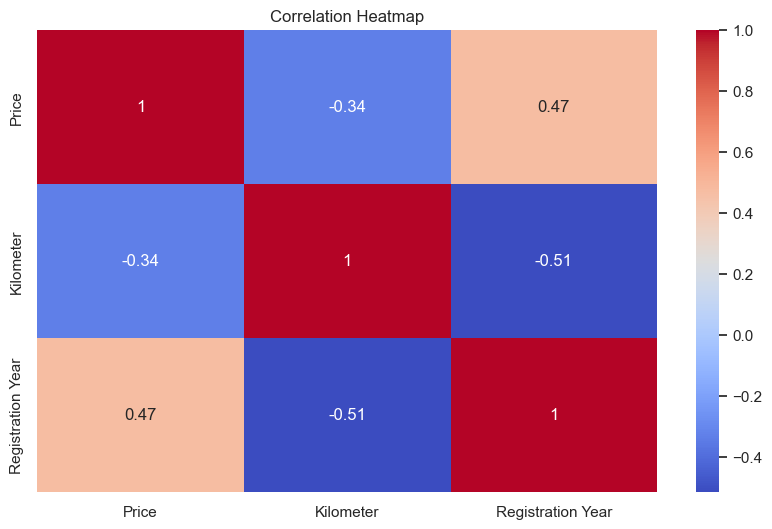

In [7]:

num_cols = bike[['Price', 'Kilometer', 'Registration Year']]
corr = num_cols.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
